# SMR multilink modelization


The following code is based in: 
- [basic example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html) and - [Biomass example](https://pypsa.readthedocs.io/en/latest/examples/biomass-synthetic-fuels-carbon-management.html).
- Previous work developed by Antonio Vaya and Daniel Juiz. 

**The code runs correctly without "infeasible error" with a multiple output from the SMR.** But, it's seems to be tricky with managing costs 

In [82]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import pandas as pd

import pypsa

import packages
# conda install openpyxl

## Costs input (2023)
Units: 
  - Investment: USD/kWe
  - FOM: USD/kW/year
  - VOM: USD/MWh
  - Fuel: USD/MWh
  - Lifetime: years
  - Carbon_cost: USD/ton
  - carbon_intensity: gCO2/kWh
  - Capacity: MW
  - Constrution time: years
  - load_factor: Unitarized
  - Tax: Unitarized
  - Rate: Unitarized 

In [83]:
#This line comented can be used to updated the costs from a cost_final24.xlsx Excel file

# #read from an excel file which is converted to csv
# cost=pd.read_excel('./cost_final24.xlsx')
# # Specify the output CSV file path
# csv_file11 = "./cost_final24.csv"
# # Save the DataFrame as a CSV file
# cost.to_csv(csv_file11, index=False)

# #Costs updated, cost.final24.csv in directory, saved in the cost Data Frame

cost=pd.read_csv('./cost_final24.csv', index_col=0)

### Calculate LCOE for each tech

In [84]:
# Compute all LCOEs
df = pd.DataFrame()
techs=['CCGT','onwind','solar','coal','nuclear','nuclear_lto','ror','battery','hydro','pumped','offwind' ]

for tech in techs:
    df=pd.concat([df, packages.LCOE(tech, cost, tech)])

df

,investment,FOM,VOM,fuel,carbon_cost,tax
technology,,,,,,
CCGT,7.051935,2.708506,1.827,50.00,0.0,0.0
onwind,30.149409,9.512938,0.000,0.00,0.0,0.0
solar,28.532850,10.388128,0.000,0.00,0.0,0.0
coal,12.184856,2.773704,5.250,30.00,0.0,0.0
nuclear,51.989628,13.430030,2.000,9.33,0.0,0.0
nuclear_lto,14.039011,13.430030,4.000,9.33,0.0,0.0
ror,27.732746,9.512938,0.000,0.00,0.0,0.0
battery,19.908540,8.219178,0.000,0.00,0.0,0.0
hydro,100.713656,22.831050,0.000,0.00,0.0,0.0


In [96]:
#Sum LCOEs components

# df.sum(axis=1).sort_values(ascending=False).plot.bar()

#Breakdown LCOE
df['Total'] = df.sum(axis=1)
df = df.sort_values(by='Total', ascending=False)
df = df.drop(columns=['Total'])

# df.plot(kind='bar', stacked=True, figsize=(10, 6))
# plt.xlabel('Technology')
# plt.ylabel('USD/MWh')
# plt.title('LCOE by technology')
# plt.show()

Add carbon costs, from the 2024 World Energy Outlook [website](https://www.iea.org/reports/world-energy-outlook-2024).

In [86]:
#Updated from 85 to 90 USD/tonCO2 by 2024 World Energy Outlook.
cost.loc["CCGT", "carbon_cost"]=90.
cost.loc["coal", "carbon_cost"]=90.

df2 = pd.DataFrame()
for tech in techs:
    df2=pd.concat([df2, packages.LCOE(tech, cost, tech)])
    
df2['Total'] = df2.sum(axis=1)
df2 = df2.sort_values(by='Total', ascending=False)
df2 = df2.drop(columns=['Total'])

# df2.plot(kind='bar', stacked=True, figsize=(10, 6))
# plt.xlabel('Technology')
# plt.ylabel('USD/MWh')
# plt.title('LCOE by technology')
# plt.show()


### Add taxes to nuclear energy
Taken from PWC's report. [website](https://www.pwc.es/es/publicaciones/energia/assets/fiscalidad-parque-nuclear.pdf)

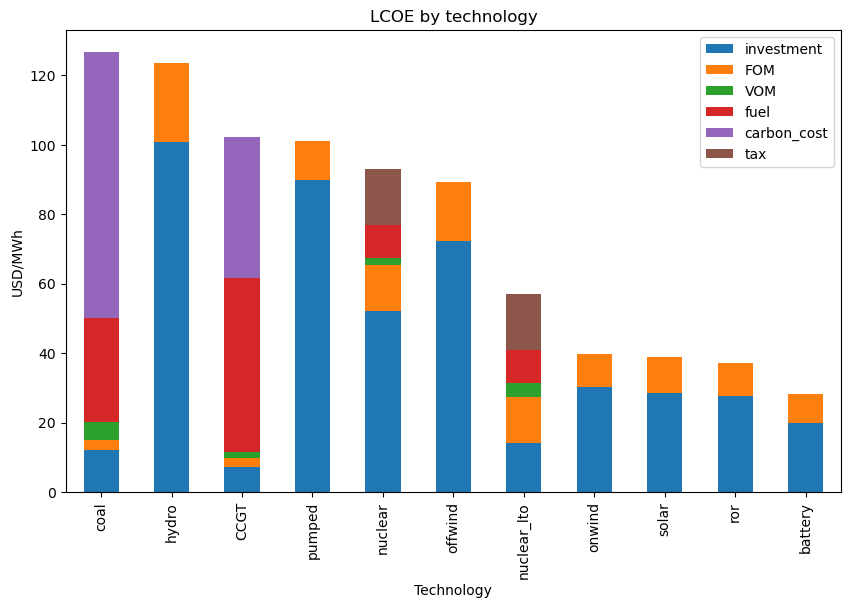

In [87]:
cost["tax"] = cost["tax"].astype(float)

#impact of taxes, 16.31 // Soruce PWC 

cost.loc["nuclear_lto", "tax"]=16.31
cost.loc["nuclear", "tax"]=16.31

df3 = pd.DataFrame()
for tech in techs:
    df3=pd.concat([df3, packages.LCOE(tech, cost, tech)])

df3['Total'] = df3.sum(axis=1)
df3 = df3.sort_values(by='Total', ascending=False)
df3 = df3.drop(columns=['Total'])

df3.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Technology')
plt.ylabel('USD/MWh')
plt.title('LCOE by technology')
plt.show()

### 2023 historical data: profiles, loads and prices
Source:  [ENTSOE Transparency Platform](https://newtransparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YES-REE------0%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%5B%222024%22%2C%222024%22%5D%2C%22tz%22%3A%22CET%22%7D)

In [88]:
#read profiles // they are all updated as of capacities and load factors of 2023

#read from an excel file which is converted to csv
profilesexcel=pd.read_excel('./allprofiles_ES_2023.xlsx')
# Specify the output CSV file path
csv_file = "./allprofiles_ES_2023.csv"
# Save the DataFrame as a CSV file
profilesexcel.to_csv(csv_file, index=False)

#Same method
loadESexcel=pd.read_excel('./load_ES_2023.xlsx')
csv_file2 = "./load_ES_2023.csv"
loadESexcel.to_csv(csv_file2, index=False)

profiles=pd.read_csv('./allprofiles_ES_2023.csv')
loadES=pd.read_csv('./load_ES_2023.csv')

# Price_ES=pd.read_csv('./ES_Price.csv'): me da error

### Annualize investment values

In [89]:
#annualiazed investment costs

lifetime= cost["lifetime"].values

annualized_inv=[packages.annualized(val, cost.loc["CCGT","rate"], lifetime[i])*1000 for i, val 
in enumerate(cost["investment"].values)] #USD/MW/y

#Add to dataframe cost
cost["annualized_investment"]=annualized_inv

### Add Carbon intensity values for techs that have CO2 emissions

In [90]:
#Adding carbon intensity in tCO2/MWh_th

cost["carbon_intensity"] = cost["carbon_intensity"].astype(float)

cost.loc["CCGT", "carbon_intensity"]=cost.loc["CCGT", "carbon_intensity"]*0.5/1000
cost.loc["coal", "carbon_intensity"]=cost.loc["coal", "carbon_intensity"]*0.4/1000
cost

,investment,FOM,VOM,lifetime,efficiency,construction_time,fuel,carbon_intensity,capacity,load_factor,rate,tax,carbon_cost,annualized_investment
technology,,,,,,,,,,,,,,
nuclear,6000,100.000000,2.000,60,0.00,7,9.33,0.000,1000,0.85,0.05,16.31,0,316969.107163
nuclear_lto,750,100.000000,4.000,10,0.00,2,9.33,0.000,1000,0.85,0.05,16.31,0,97128.431224
onwind,1160,25.000000,0.000,30,0.00,1,0.00,0.000,50,0.30,0.05,0.00,0,75459.664693
solar,671,18.200000,0.000,25,0.00,1,0.00,0.000,50,0.20,0.05,0.00,0,47609.098848
CCGT,750,20.167539,1.827,30,0.59,2,50.00,0.225,500,0.85,0.05,0.00,90,48788.576310
coal,1376,20.653000,5.250,40,0.45,4,30.00,0.340,500,0.85,0.05,0.00,90,80190.749764
battery,862,36.000000,0.000,15,0.00,1,0.00,0.000,100,0.50,0.05,0.00,0,83047.051919
hydro,2806,40.000000,0.000,60,0.00,6,0.00,0.000,500,0.20,0.05,0.00,0,148235.885783
ror,2318,50.000000,0.000,60,0.00,6,0.00,0.000,5,0.60,0.05,0.00,0,122455.731734


### Add carriers to analyze enegry flows

In [91]:
#Add one for each technology to analyze energy flows per carrier
#Their attributes are a arbitrary name and the carbon intensity value coming from the cost Data Frame

network.add("Carrier",
      "Gas",
      co2_emissions=cost.loc["CCGT","carbon_intensity"])

network.add("Carrier",
      "Nuclear",
      co2_emissions=cost.loc["nuclear","carbon_intensity"])

Index(['Nuclear'], dtype='object')

## SMR vs Gas combined heat power + electric grid

In [92]:
network = pypsa.Network() # Creates empty PyPSA network object called network
network.set_snapshots(range(10)) #set time frame of simulation
# marginal costs in EUR/MWh
marginal_costs = {"uranium": 10, "Spain_gas": 30, "Spain_grid": 50}

# 0) define carriers (optional)
network.add("Carrier", "Gas",
            co2_emissions=cost.loc["CCGT","carbon_intensity"]) 
network.add("Carrier", "nuclear",)
network.add("Carrier", "heat",)
network.add("Carrier","electricity",)

network.add("Bus", "Industry Electricity", carrier="electricity") # 1) Main Buses & loads
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=6)

network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=4)

network.add("Bus", "uranium_UO2", carrier="nuclear")                  # 2)  Fuel buses
network.add("Bus", "Spain_gas", carrier="Gas")
network.add("Bus", "Spain_grid", carrier="electricity")
#---------------------------------------------------------------------------------------
network.add("Store", "Spain gas", bus="Spain_gas",
    e_initial=100, 
    e_nom=50,    # set pre-existing e_nom=50?
    e_nom_extendable=True, # 
    # capital_cost=1,
    marginal_cost=pd.Series([10,10,15,30,35,28,20,19,10,10], index=network.snapshots) 
)
network.add( "Link", "Link_Gas_CHP",               
    bus0="Spain_gas",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="Gas",
    p_nom=10,            # fixed p_nom Gas installed
    capital_cost=1,     # fixed period costs of extending p_nom by 1 MW
    efficiency=0.6, 
    efficiency2=0.4,
)
#---------------------------------------------------------------------------------------
network.add("Store", "uranium", bus="uranium_UO2",
    e_initial=100, 
    e_nom=0, # set pre-existing e_nom=0?
    e_nom_extendable=True,
    # capital_cost=1,  
    marginal_cost=marginal_costs["uranium"]
) 
network.add( "Link", "Link_SMR_CHP",
    bus0="uranium_UO2",
    bus1="Industry Electricity",
    bus2="Industry Heat", 
    carrier="nuclear",
    # p_nom=10,
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=1, #annualized USD
    efficiency=0.6, 
    efficiency2=0.4,
)
#---------------------------------------------------------------------------------------
network.add("Store", "Spain grid", bus="Spain_grid",
    e_initial=1e7, 
    e_nom=100, # set pre-existing e_nom=0?
    e_nom_extendable=True,
    # capital_cost=1,  
    marginal_cost=marginal_costs["Spain_grid"]
)
network.add("Link", "Link_Spain_grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    carrier="electricity",
    p_nom_extendable=True,
    capital_cost=1,    #  $/MW per period
    marginal_cost=0,  # $/MWh no aditional cost
    efficiency=0.95)      #  electricity transport

Index(['Link_Spain_grid'], dtype='object')

In [93]:
network.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.35s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 95 primals, 205 duals
Objective: 1.01e+03
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

total_cost= 1010.0 [USD]
capital cost= 0.0 [USD]
summed marginal cost= 1010.0 [USD]


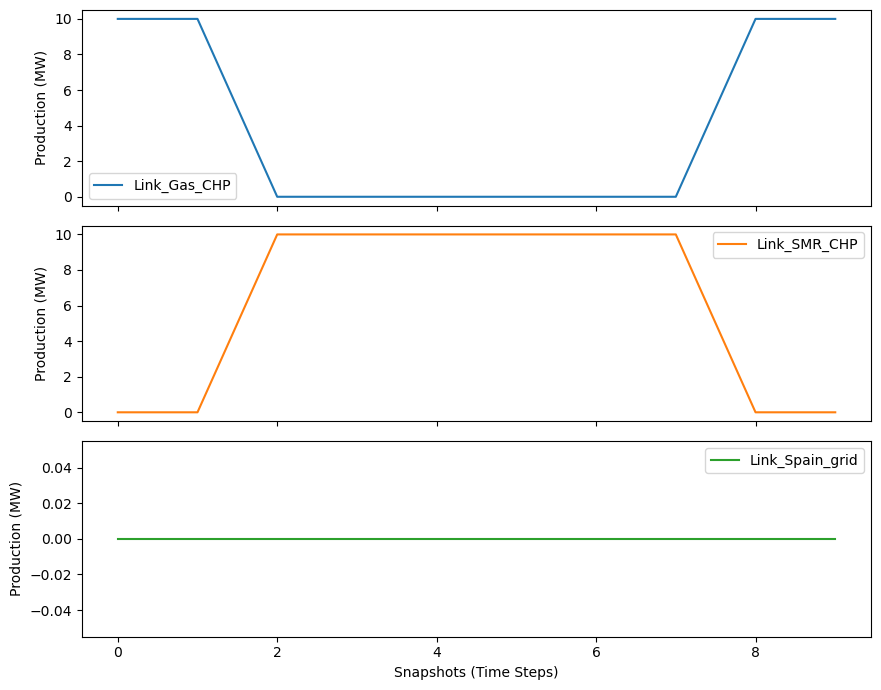

In [94]:
# Plot production view with subplots
ax = network.links_t.p0.plot(subplots=True, figsize=(9, 7))
# Add labels for x and y axes on each subplot
for subplot in ax:
    subplot.set_xlabel("Snapshots (Time Steps)")  # Label for x-axis
    subplot.set_ylabel("Production (MW)")         # Label for y-axis
# Adjust layout to prevent overlapping
plt.tight_layout()
# print(network.links.p_nom_opt)
total_cost = network.objective + network.objective_constant;  # USD
print("total_cost=", total_cost,"[USD]")
print("capital cost=", network.objective_constant, "[USD]")
print("summed marginal cost=", network.objective, "[USD]")

In [95]:
print("SMR Electricity Output:", network.links_t.p1["Link_SMR_CHP"].sum())  # -MW
print("SMR Heat Output:", network.links_t.p2["Link_SMR_CHP"].sum())         # -MW
print("SMR Uranium Fuel Consumption:", network.links_t.p0["Link_SMR_CHP"].sum())    #+ MW
print("Gas_CHP Electricity Output:", network.links_t.p1["Link_Gas_CHP"].sum())
print("Gas_CHP Gas Consumption:", network.links_t.p0["Link_Gas_CHP"].sum())

SMR Electricity Output: -36.0
SMR Heat Output: -24.0
SMR Uranium Fuel Consumption: 60.0
Gas_CHP Electricity Output: -24.0
Gas_CHP Gas Consumption: 40.0


Note that negative values for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive). 

- network.links_t.p0 # energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE
- network.links_t.p1 # energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)
- network.links_t.p2 # energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)

<!-- Note that `negative values` for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive).

Here there is a brief explanation for each of the following code lines: 
- network.links_t.p0: `energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE`
- network.links_t.p1: `energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)`
- network.links_t.p2: `energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)` -->

<!-- 
Starts SMR model versión2 with network `n2`

## Note: 
About de network initialization (can be useful for some future research)

**Network Initialization**: `n1 = pypsa.Network(url)`
   - Creates a PyPSA `Network` object `n1`
   - Automatically downloads and loads the pre-configured energy system model containing:
     - Buses (energy nodes)
     - Generators (power plants)
     - Loads (energy demands)
     - Transmission lines
     - Time-dependent constraints

Key Features of This Approach:
- **Reproducibility**: Loads a standardized benchmark model
- **Time-Saving**: Avoids manual network construction (~1000+ lines of setup code)
- **Research-Ready**: Contains realistic European power system data (likely from [PyPSA-Eur](https://pypsa-eur.readthedocs.io/)) -->